# IPL Live Win Probability Predictor
Synent Technologies Data Science Internship | Task 9

Candidate: Hit Goyani
Candidate ID: SYN/M2/IP1050

This notebook transforms official Cricsheet IPL JSON data into a second-innings chase modeling dataset, trains two baseline classifiers, evaluates calibration, and saves the final pipeline artifact.

## Phase 1 - Imports and Paths

In [41]:
import json
import math
import re
import time
import zipfile
from collections import deque
from pathlib import Path
from urllib.request import urlretrieve

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

start_time = time.time()

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# Bulletproof path resolution independent of CWD
cwd = Path.cwd()
if (cwd / 'ipl_live_win_predictor.ipynb').exists() or cwd.name == 'notebook':
    NOTEBOOK_DIR = cwd if (cwd / 'ipl_live_win_predictor.ipynb').exists() else cwd / 'notebook'
    PROJECT_ROOT = NOTEBOOK_DIR.parent
elif (cwd / 'notebook' / 'ipl_live_win_predictor.ipynb').exists():
    PROJECT_ROOT = cwd
    NOTEBOOK_DIR = cwd / 'notebook'
elif (cwd / 'Task9-IPLScorePredictor' / 'notebook' / 'ipl_live_win_predictor.ipynb').exists():
    PROJECT_ROOT = cwd / 'Task9-IPLScorePredictor'
    NOTEBOOK_DIR = PROJECT_ROOT / 'notebook'
else:
    PROJECT_ROOT = cwd
    NOTEBOOK_DIR = cwd / 'notebook'

DATA_DIR = PROJECT_ROOT / 'data'
MODEL_DIR = PROJECT_ROOT / 'model'
IMAGE_DIR = PROJECT_ROOT / 'images'

# Ensure output directories exist
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

RAW_JSON_ZIP = DATA_DIR / 'ipl_json.zip'
EXTRACT_DIR = DATA_DIR / 'cricsheet_ipl_json'
PROCESSED_DATA_PATH = DATA_DIR / 'ipl_live_win_predictor_dataset.csv'
MODEL_PATH = MODEL_DIR / 'model.pkl'
CRICSHEET_IPL_URL = 'https://cricsheet.org/downloads/ipl_json.zip'
RANDOM_STATE = 42

print(f'Notebook directory: {NOTEBOOK_DIR}')
print(f'Project root: {PROJECT_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Model directory: {MODEL_DIR}')
print(f'Phase completed in {time.time() - start_time:.2f} seconds')

Notebook directory: c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\notebook
Project root: c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor
Data directory: c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\data
Model directory: c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\model
Phase completed in 0.00 seconds


## Phase 2 - Download and Extract Cricsheet IPL JSON

In [42]:
start_time = time.time()

def ensure_download(url: str, target_path: Path) -> None:
    target_path.parent.mkdir(parents=True, exist_ok=True)
    if not target_path.exists():
        print(f'Downloading {target_path.name} ...')
        urlretrieve(url, target_path)


def ensure_extracted(archive_path: Path, extract_dir: Path) -> None:
    extract_dir.mkdir(parents=True, exist_ok=True)
    marker = extract_dir / '.extracted'
    if marker.exists():
        return
    print(f'Extracting {archive_path.name} ...')
    with zipfile.ZipFile(archive_path, 'r') as archive:
        archive.extractall(extract_dir)
    marker.write_text('ok', encoding='utf-8')


ensure_download(CRICSHEET_IPL_URL, RAW_JSON_ZIP)
ensure_extracted(RAW_JSON_ZIP, EXTRACT_DIR)
print(f'Archive ready: {RAW_JSON_ZIP.exists()}')
print(f'Extracted directory ready: {EXTRACT_DIR.exists()}')
print(f'Phase completed in {time.time() - start_time:.2f} seconds')

Archive ready: True
Extracted directory ready: True
Phase completed in 0.00 seconds


## Phase 3 - Normalization and Match Filters

In [43]:
start_time = time.time()

TEAM_ALIASES = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Rising Pune Supergiants': 'Rising Pune Supergiants',
    'Sunrisers': 'Sunrisers Hyderabad',
}

VENUE_ALIASES = {
    'M. Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali': 'Punjab Cricket Association Stadium, Mohali',
    'Feroz Shah Kotla Ground': 'Feroz Shah Kotla',
    'Brabourne Stadium, Mumbai': 'Brabourne Stadium',
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium, Chepauk',
}

EXCLUDED_METHODS = {'D/L', 'VJD', 'Awarded', '1st innings score', 'Lost fewer wickets'}

def normalize_team(name):
    if not isinstance(name, str):
        return 'Unknown'
    return TEAM_ALIASES.get(name.strip(), name.strip())


def normalize_venue(name):
    if not isinstance(name, str) or not name.strip():
        return 'Unknown'
    cleaned = re.sub(r'\s+', ' ', name.strip())
    return VENUE_ALIASES.get(cleaned, cleaned)


def season_sort_key(season):
    text = str(season)
    match = re.match(r'^(\d{4})', text)
    if match:
        return int(match.group(1))
    numbers = re.findall(r'\d+', text)
    return int(numbers[0]) if numbers else 9999


def is_eligible_match(info):
    outcome = info.get('outcome', {})
    if outcome.get('result') in {'no result', 'tie', 'draw'}:
        return False
    if outcome.get('method') in EXCLUDED_METHODS:
        return False
    if not outcome.get('winner'):
        return False
    if any(innings.get('super_over') for innings in info.get('innings', [])):
        return False
    return True


def innings_total(innings_obj):
    total = 0
    for over in innings_obj.get('overs', []):
        for delivery in over.get('deliveries', []):
            total += delivery.get('runs', {}).get('total', 0)
    penalty_runs = innings_obj.get('penalty_runs', {}) or {}
    total += penalty_runs.get('pre', 0)
    total += penalty_runs.get('post', 0)
    return int(total)

print("Normalization functions and match eligibility filters defined.")
print(f'Phase completed in {time.time() - start_time:.2f} seconds')

Normalization functions and match eligibility filters defined.
Phase completed in 0.00 seconds


## Phase 4 - Flatten Matches Into Chase Rows

### Why second innings?
First innings score prediction does not reflect live match dynamics. This project models second-innings chase states and predicts win probability using official Cricsheet data.

In [44]:
start_time = time.time()

def flatten_match(match_path):
    with open(match_path, 'r', encoding='utf-8') as file_handle:
        match_data = json.load(file_handle)

    info = match_data.get('info', {})
    if not is_eligible_match(info):
        return []

    innings_list = match_data.get('innings', [])
    if len(innings_list) < 2:
        return []

    first_innings = innings_list[0]
    second_innings = innings_list[1]

    teams = [normalize_team(team) for team in info.get('teams', [])]
    if len(teams) != 2:
        return []

    batting_team = normalize_team(second_innings.get('team'))
    bowling_team = teams[0] if teams[1] == batting_team else teams[1]
    winner = normalize_team(info.get('outcome', {}).get('winner'))
    season = str(info.get('season', 'Unknown'))
    match_date = str((info.get('dates') or ['Unknown'])[0])
    venue = normalize_venue(info.get('venue'))
    target = innings_total(first_innings) + 1
    match_id = match_path.stem
    chase_won = int(winner == batting_team)

    current_runs = 0
    current_wickets = 0
    balls_completed = 0
    recent_runs = deque(maxlen=30)
    recent_wickets = deque(maxlen=30)
    rows = []

    for over in second_innings.get('overs', []):
        for delivery in over.get('deliveries', []):
            delivery_total = int(delivery.get('runs', {}).get('total', 0))
            wicket_count = len(delivery.get('wickets', []))
            extras = delivery.get('extras', {}) or {}
            is_legal_delivery = ('wides' not in extras) and ('noballs' not in extras)

            current_runs += delivery_total
            current_wickets += wicket_count

            if is_legal_delivery:
                balls_completed += 1
                recent_runs.append(delivery_total)
                recent_wickets.append(wicket_count)

                if current_runs < target:
                    balls_remaining = 120 - balls_completed
                    runs_required = target - current_runs
                    over_progress = balls_completed / 6 if balls_completed else 0.0
                    current_run_rate = current_runs / over_progress if over_progress else 0.0
                    required_run_rate = runs_required / (balls_remaining / 6) if balls_remaining > 0 else 0.0

                    rows.append({
                        'match_id': match_id,
                        'season': season,
                        'date': match_date,
                        'venue': venue,
                        'batting_team': batting_team,
                        'bowling_team': bowling_team,
                        'target': target,
                        'current_runs': current_runs,
                        'current_wickets': current_wickets,
                        'balls_completed': balls_completed,
                        'balls_remaining': balls_remaining,
                        'runs_required': runs_required,
                        'current_run_rate': current_run_rate,
                        'required_run_rate': required_run_rate,
                        'runs_last_30_legal_deliveries': int(sum(recent_runs)),
                        'wickets_last_30_legal_deliveries': int(sum(recent_wickets)),
                        'target_label': chase_won,
                    })
                else:
                    break

        else:
            continue
        break

    return rows

try:
    import pyarrow
    USE_PARQUET = True
except ImportError:
    USE_PARQUET = False

PROCESSED_PARQUET_PATH = DATA_DIR / 'chase_dataset.parquet'
PROCESSED_CSV_CACHE_PATH = DATA_DIR / 'chase_dataset_cache.csv'

if USE_PARQUET and PROCESSED_PARQUET_PATH.exists():
    print(f'Loading cached dataset from {PROCESSED_PARQUET_PATH} ...')
    chase_df = pd.read_parquet(PROCESSED_PARQUET_PATH)
elif not USE_PARQUET and PROCESSED_CSV_CACHE_PATH.exists():
    print(f'Loading cached dataset from {PROCESSED_CSV_CACHE_PATH} ...')
    chase_df = pd.read_csv(PROCESSED_CSV_CACHE_PATH, dtype={'season': str})
else:
    json_files = sorted(EXTRACT_DIR.rglob('*.json'))
    print(f'Found {len(json_files)} match files')

    all_rows = []
    for match_file in json_files:
        all_rows.extend(flatten_match(match_file))

    chase_df = pd.DataFrame(all_rows)
    
    if USE_PARQUET:
        chase_df.to_parquet(PROCESSED_PARQUET_PATH, index=False)
        print(f'Processed dataset saved to cache at {PROCESSED_PARQUET_PATH}')
    else:
        chase_df.to_csv(PROCESSED_CSV_CACHE_PATH, index=False)
        print(f'Processed dataset saved to cache at {PROCESSED_CSV_CACHE_PATH}')

print('Flattened dataset shape:', chase_df.shape)
print(f'Phase completed in {time.time() - start_time:.2f} seconds')
chase_df.head()

Loading cached dataset from c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\data\chase_dataset.parquet ...
Flattened dataset shape: (132877, 17)
Phase completed in 0.01 seconds


,match_id,season,date,venue,batting_team,bowling_team,target,current_runs,current_wickets,balls_completed,balls_remaining,runs_required,current_run_rate,required_run_rate,runs_last_30_legal_deliveries,wickets_last_30_legal_deliveries,target_label
0,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,Sunrisers Hyderabad,208,1,0,1,119,207,6.0,10.436975,1,0,0
1,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,Sunrisers Hyderabad,208,1,0,2,118,207,3.0,10.525424,1,0,0
2,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,Sunrisers Hyderabad,208,1,0,3,117,207,2.0,10.615385,1,0,0
3,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,Sunrisers Hyderabad,208,3,0,4,116,205,4.5,10.603448,3,0,0
4,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,Sunrisers Hyderabad,208,7,0,5,115,201,8.4,10.486957,7,0,0


## Phase 5 - Data Audit and Season Detection

In [45]:
start_time = time.time()

if chase_df.empty:
    raise ValueError('No chase rows were generated. Check the downloaded Cricsheet files and filters.')

available_seasons = sorted(chase_df['season'].dropna().unique(), key=season_sort_key)
print('Available seasons:', available_seasons)
print('Minimum season:', min(available_seasons, key=season_sort_key))
print('Maximum season:', max(available_seasons, key=season_sort_key))
print()
print('Target label distribution:')
print(chase_df['target_label'].value_counts().sort_index())

chase_df.to_csv(PROCESSED_DATA_PATH, index=False)
print(f'Processed dataset saved to {PROCESSED_DATA_PATH}')
print(f'Phase completed in {time.time() - start_time:.2f} seconds')

Available seasons: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025', '2026']
Minimum season: 2007/08
Maximum season: 2026

Target label distribution:
target_label
0    63497
1    69380
Name: count, dtype: int64
Processed dataset saved to c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\data\ipl_live_win_predictor_dataset.csv
Phase completed in 0.56 seconds


## Phase 6 - Chronological Train / Validation / Test Split

### Why chronological splitting?
Random delivery-level splitting introduces optimistic estimates due to within-match autocorrelation. Therefore, entire matches are kept intact and seasons are split chronologically.

In [46]:
start_time = time.time()

def split_seasons(seasons):
    season_count = len(seasons)
    if season_count < 3:
        raise ValueError('At least 3 seasons are required for train/validation/test splitting.')

    train_end = max(1, int(math.floor(season_count * 0.8)))
    val_end = max(train_end + 1, int(math.floor(season_count * 0.9)))
    if val_end >= season_count:
        val_end = season_count - 1
    if train_end >= val_end:
        train_end = max(1, val_end - 1)

    train_seasons = seasons[:train_end]
    validation_seasons = seasons[train_end:val_end]
    test_seasons = seasons[val_end:]

    if not validation_seasons:
        validation_seasons = [seasons[-2]]
        train_seasons = seasons[:-2]
        test_seasons = [seasons[-1]]

    return train_seasons, validation_seasons, test_seasons


train_seasons, validation_seasons, test_seasons = split_seasons(available_seasons)
print('Train seasons:', train_seasons)
print('Validation seasons:', validation_seasons)
print('Test seasons:', test_seasons)

# Save split information
split_info = {
    'train': train_seasons,
    'validation': validation_seasons,
    'test': test_seasons
}
split_path = MODEL_DIR / 'train_val_test_split.json'
split_path.write_text(json.dumps(split_info, indent=2), encoding='utf-8')
print(f'Split information saved to {split_path}')

train_df = chase_df[chase_df['season'].isin(train_seasons)].copy()
validation_df = chase_df[chase_df['season'].isin(validation_seasons)].copy()
test_df = chase_df[chase_df['season'].isin(test_seasons)].copy()

print('Train shape:', train_df.shape)
print('Validation shape:', validation_df.shape)
print('Test shape:', test_df.shape)
print(f'Phase completed in {time.time() - start_time:.2f} seconds')

Train seasons: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022']
Validation seasons: ['2023', '2024']
Test seasons: ['2025', '2026']
Split information saved to c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\model\train_val_test_split.json
Train shape: (101771, 17)
Validation shape: (15857, 17)
Test shape: (15249, 17)
Phase completed in 0.03 seconds


## Phase 7 - Feature Set Finalization

In [47]:
start_time = time.time()

feature_columns = [
    'season',
    'venue',
    'batting_team',
    'bowling_team',
    'target',
    'current_runs',
    'current_wickets',
    'balls_completed',
    'balls_remaining',
    'runs_required',
    'current_run_rate',
    'required_run_rate',
    'runs_last_30_legal_deliveries',
    'wickets_last_30_legal_deliveries',
]

target_column = 'target_label'

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()
X_validation = validation_df[feature_columns].copy()
y_validation = validation_df[target_column].copy()
X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

categorical_features = ['season', 'venue', 'batting_team', 'bowling_team']
numeric_features = [
    'target',
    'current_runs',
    'current_wickets',
    'balls_completed',
    'balls_remaining',
    'runs_required',
    'current_run_rate',
    'required_run_rate',
    'runs_last_30_legal_deliveries',
    'wickets_last_30_legal_deliveries',
]

print('Training class distribution:')
print(y_train.value_counts(normalize=True).sort_index())
print('Validation class distribution:')
print(y_validation.value_counts(normalize=True).sort_index())
print('Test class distribution:')
print(y_test.value_counts(normalize=True).sort_index())
print(f'Phase completed in {time.time() - start_time:.2f} seconds')

Training class distribution:
target_label
0    0.472777
1    0.527223
Name: proportion, dtype: float64
Validation class distribution:
target_label
0    0.545248
1    0.454752
Name: proportion, dtype: float64
Test class distribution:
target_label
0    0.441734
1    0.558266
Name: proportion, dtype: float64
Phase completed in 0.01 seconds


## Phase 8 - Modeling Pipelines

In [48]:
start_time = time.time()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', categorical_transformer, categorical_features),
        ('numeric', numeric_transformer, numeric_features),
    ]
)

logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
])

random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight='balanced_subsample',
        min_samples_leaf=2,
        n_jobs=-1,
    )),
])

candidate_models = {
    'logistic_regression': logistic_model,
    'random_forest': random_forest_model,
}

def evaluate_classifier(model, x_data, y_data):
    predicted_probabilities = model.predict_proba(x_data)[:, 1]
    predicted_labels = (predicted_probabilities >= 0.5).astype(int)
    return {
        'accuracy': accuracy_score(y_data, predicted_labels),
        'precision': precision_score(y_data, predicted_labels, zero_division=0),
        'recall': recall_score(y_data, predicted_labels, zero_division=0),
        'f1': f1_score(y_data, predicted_labels, zero_division=0),
        'roc_auc': roc_auc_score(y_data, predicted_probabilities),
        'brier': brier_score_loss(y_data, predicted_probabilities),
        'probabilities': predicted_probabilities,
        'predictions': predicted_labels,
    }

for model_name, model in candidate_models.items():
    model.fit(X_train, y_train)
    validation_metrics = evaluate_classifier(model, X_validation, y_validation)
    print(f'[{model_name}] validation metrics')
    print({k: round(v, 4) for k, v in validation_metrics.items() if k not in {'probabilities', 'predictions'}})
    print()

print(f'Phase completed in {time.time() - start_time:.2f} seconds')

[logistic_regression] validation metrics
{'accuracy': 0.7534, 'precision': 0.7968, 'recall': 0.6145, 'f1': 0.6939, 'roc_auc': 0.8245, 'brier': 0.1862}

[random_forest] validation metrics
{'accuracy': 0.7825, 'precision': 0.7906, 'recall': 0.7096, 'f1': 0.7479, 'roc_auc': 0.8446, 'brier': 0.1595}

Phase completed in 9.47 seconds


## Phase 9 - Reliability Diagram and Final Model Selection

### Why Random Forest?
Random Forest improved ROC-AUC while maintaining reasonable calibration compared to the logistic regression baseline.

The random forest calibration step is conditional. Inspect the reliability diagram before enabling calibration.

                 model  accuracy  precision    recall        f1   roc_auc     brier
0  logistic_regression  0.753421   0.796799  0.614478  0.693862  0.824524  0.186203
1        random_forest  0.782494   0.790637  0.709610  0.747935  0.844600  0.159517
Saved validation reliability diagram to c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\images\reliability_diagram_val.png


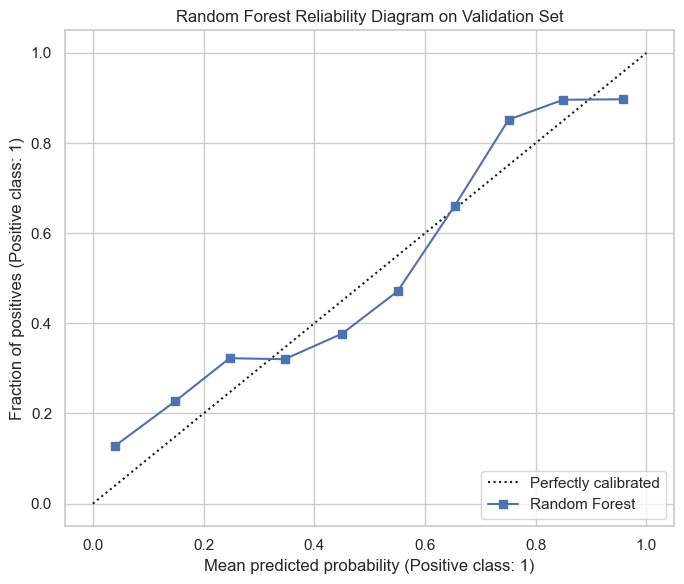

Best model by validation ROC-AUC: random_forest
Selected final model: random_forest
Phase completed in 0.64 seconds


In [49]:
start_time = time.time()

logistic_validation = evaluate_classifier(logistic_model, X_validation, y_validation)
random_forest_validation = evaluate_classifier(random_forest_model, X_validation, y_validation)

validation_summary = pd.DataFrame([
    {'model': 'logistic_regression', **{k: v for k, v in logistic_validation.items() if k not in {'probabilities', 'predictions'}}},
    {'model': 'random_forest', **{k: v for k, v in random_forest_validation.items() if k not in {'probabilities', 'predictions'}}},
])
print(validation_summary)

fig, ax = plt.subplots(figsize=(7, 6))
CalibrationDisplay.from_predictions(
    y_validation,
    random_forest_validation['probabilities'],
    n_bins=10,
    name='Random Forest',
    ax=ax,
)
ax.set_title('Random Forest Reliability Diagram on Validation Set')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'reliability_diagram_val.png', dpi=300, bbox_inches='tight')
print(f"Saved validation reliability diagram to {IMAGE_DIR / 'reliability_diagram_val.png'}")
plt.show()

best_model_name = validation_summary.sort_values('roc_auc', ascending=False).iloc[0]['model']
print('Best model by validation ROC-AUC:', best_model_name)

CALIBRATE_RANDOM_FOREST = False

if best_model_name == 'random_forest' and CALIBRATE_RANDOM_FOREST:
    final_model = CalibratedClassifierCV(estimator=random_forest_model, cv='prefit', method='sigmoid')
    final_model.fit(X_validation, y_validation)
    final_model_name = 'calibrated_random_forest'
elif best_model_name == 'random_forest':
    final_model = random_forest_model
    final_model_name = 'random_forest'
else:
    final_model = logistic_model
    final_model_name = 'logistic_regression'

print('Selected final model:', final_model_name)
print(f'Phase completed in {time.time() - start_time:.2f} seconds')

## Phase 10 - Final Test Evaluation

{'accuracy': 0.7867, 'precision': 0.9133, 'recall': 0.6827, 'f1': 0.7813, 'roc_auc': 0.8933, 'brier': 0.146}

              precision    recall  f1-score   support

           0       0.70      0.92      0.79      6736
           1       0.91      0.68      0.78      8513

    accuracy                           0.79     15249
   macro avg       0.80      0.80      0.79     15249
weighted avg       0.82      0.79      0.79     15249

Saved confusion matrix to c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\images\confusion_matrix.png


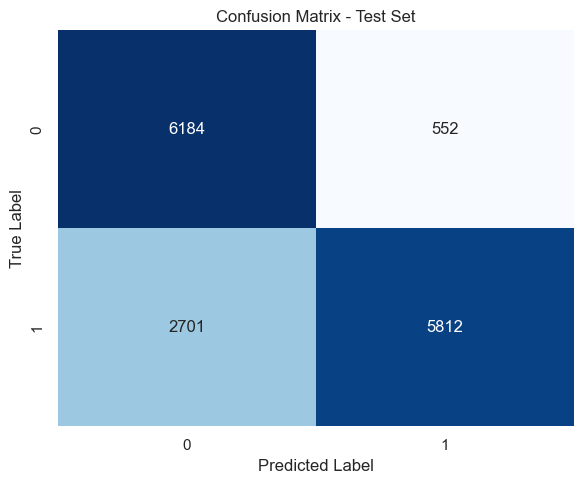

Saved ROC curve to c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\images\roc_curve.png


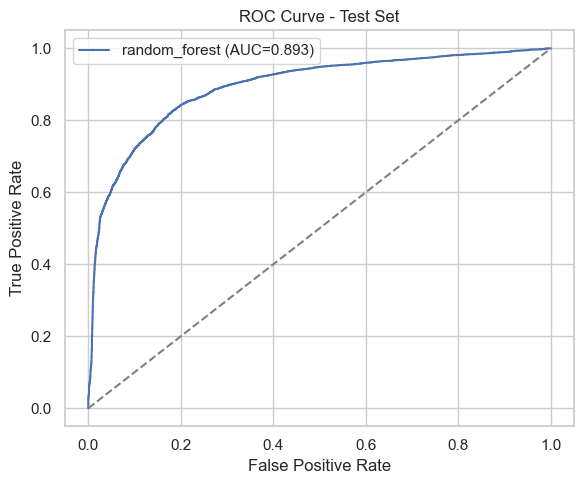

Saved reliability diagram to c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\images\reliability_diagram.png


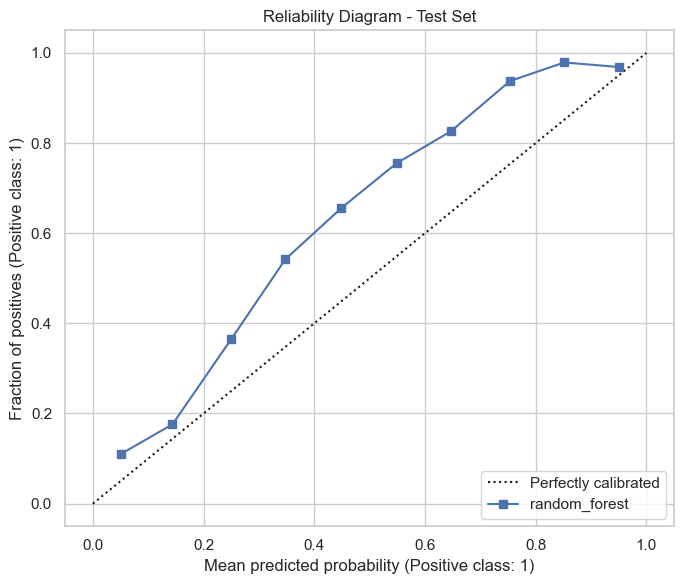

Saved feature importance plot to c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\images\feature_importance.png


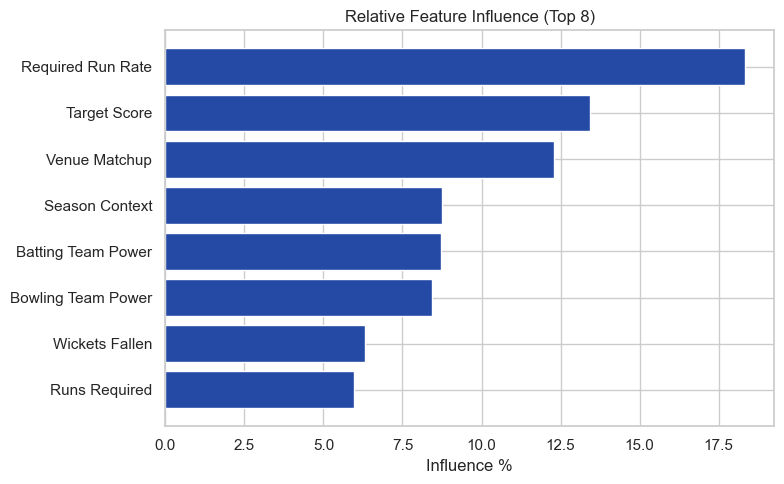

In [50]:
start_time = time.time()

if final_model_name in {'logistic_regression', 'random_forest'}:
    final_model.fit(pd.concat([X_train, X_validation], axis=0), pd.concat([y_train, y_validation], axis=0))

test_metrics = evaluate_classifier(final_model, X_test, y_test)
print({k: round(v, 4) for k, v in test_metrics.items() if k not in {'probabilities', 'predictions'}})
print()
print(classification_report(y_test, test_metrics['predictions'], zero_division=0))

# 1. Confusion Matrix
conf_matrix = confusion_matrix(y_test, test_metrics['predictions'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('Confusion Matrix - Test Set')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
print(f"Saved confusion matrix to {IMAGE_DIR / 'confusion_matrix.png'}")
plt.show()

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_metrics['probabilities'])
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f'{final_model_name} (AUC={test_metrics["roc_auc"]:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='grey')
ax.set_title('ROC Curve - Test Set')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'roc_curve.png', dpi=300, bbox_inches='tight')
print(f"Saved ROC curve to {IMAGE_DIR / 'roc_curve.png'}")
plt.show()

# 3. Reliability Diagram
fig, ax = plt.subplots(figsize=(7, 6))
CalibrationDisplay.from_predictions(y_test, test_metrics['probabilities'], n_bins=10, name=final_model_name, ax=ax)
ax.set_title('Reliability Diagram - Test Set')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'reliability_diagram.png', dpi=300, bbox_inches='tight')
print(f"Saved reliability diagram to {IMAGE_DIR / 'reliability_diagram.png'}")
plt.show()

# 4. Feature Importance
try:
    classifier = final_model.named_steps['classifier']
    preprocessor_transformer = final_model.named_steps['preprocessor']
    importances = classifier.feature_importances_
    feature_names = preprocessor_transformer.get_feature_names_out()
    
    aggregated = {}
    for name, imp in zip(feature_names, importances):
        if name.startswith('categorical__'):
            col_name = name[len('categorical__'):]
            for cat in ['season', 'venue', 'batting_team', 'bowling_team']:
                if col_name.startswith(cat + '_'):
                    aggregated[cat] = aggregated.get(cat, 0.0) + imp
                    break
        elif name.startswith('numeric__'):
            col_name = name[len('numeric__'):]
            aggregated[col_name] = aggregated.get(col_name, 0.0) + imp
            
    friendly_names = {
        'required_run_rate': 'Required Run Rate',
        'target': 'Target Score',
        'venue': 'Venue Matchup',
        'season': 'Season Context',
        'batting_team': 'Batting Team Power',
        'bowling_team': 'Bowling Team Power',
        'current_wickets': 'Wickets Fallen',
        'runs_required': 'Runs Required',
        'current_run_rate': 'Current Run Rate',
        'wickets_last_30_legal_deliveries': 'Wickets Last 30 Balls',
        'current_runs': 'Current Score Progress',
        'runs_last_30_legal_deliveries': 'Runs Last 30 Balls',
        'balls_remaining': 'Balls Remaining',
        'balls_completed': 'Balls Completed',
    }
    sorted_imps = sorted(aggregated.items(), key=lambda x: x[1], reverse=True)
    top_n = sorted_imps[:8]
    labels = [friendly_names.get(k, k) for k, _ in top_n][::-1]
    values = [float(v) * 100 for _, v in top_n][::-1]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(labels, values, color='#254AA5')
    ax.set_title('Relative Feature Influence (Top 8)')
    ax.set_xlabel('Influence %')
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
    print(f"Saved feature importance plot to {IMAGE_DIR / 'feature_importance.png'}")
    plt.show()
except Exception as e:
    print(f"Could not compute feature importances: {e}")


## Phase 11 - Model Metrics Report

Consolidate all evaluation metrics (validation + test) into a structured table and export to:
- `model/model_metrics.html` — styled HTML table for presentation
- `model/model_metrics.csv` — machine-readable flat file

> These are **data reports**, not plots, so they belong in `model/`, not `images/`.

In [51]:
start_time = time.time()

# ── Model Metrics Summary Report ──────────────────────────────────────────────
# Aggregates validation and test set metrics for all candidate models into a
# single DataFrame, then exports both a human-readable HTML table and a
# machine-readable CSV into the model/ directory.

metrics_records = [
    {
        'split': 'Validation',
        'model': 'Logistic Regression',
        **{k: round(float(v), 4) for k, v in logistic_validation.items()
           if k not in {'probabilities', 'predictions'}},
    },
    {
        'split': 'Validation',
        'model': 'Random Forest',
        **{k: round(float(v), 4) for k, v in random_forest_validation.items()
           if k not in {'probabilities', 'predictions'}},
    },
    {
        'split': 'Test',
        'model': final_model_name.replace('_', ' ').title(),
        **{k: round(float(v), 4) for k, v in test_metrics.items()
           if k not in {'probabilities', 'predictions'}},
    },
]

metrics_df = pd.DataFrame(metrics_records)

# Reorder columns for readability
ordered_cols = ['split', 'model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'brier']
metrics_df = metrics_df[[c for c in ordered_cols if c in metrics_df.columns]]

print("Model Metrics Summary:")
print(metrics_df.to_string(index=False))
print()

# Export to model/ directory (NOT images/ — these are data reports, not plots)
metrics_html_path = MODEL_DIR / 'model_metrics.html'
metrics_csv_path  = MODEL_DIR / 'model_metrics.csv'

html_style = """
<style>
  table { border-collapse: collapse; font-family: sans-serif; font-size: 14px; }
  th, td { border: 1px solid #ccc; padding: 8px 14px; text-align: center; }
  th { background: #254AA5; color: white; }
  tr:nth-child(even) { background: #f4f6ff; }
</style>
"""
html_table = metrics_df.to_html(index=False)
metrics_html_path.write_text(html_style + html_table, encoding='utf-8')
metrics_df.to_csv(metrics_csv_path, index=False)

print(f"Saved model_metrics.html  → {metrics_html_path}")
print(f"Saved model_metrics.csv   → {metrics_csv_path}")
print(f"Phase completed in {time.time() - start_time:.2f} seconds")


Model Metrics Summary:
     split               model  accuracy  precision  recall     f1  roc_auc  brier
Validation Logistic Regression    0.7534     0.7968  0.6145 0.6939   0.8245 0.1862
Validation       Random Forest    0.7825     0.7906  0.7096 0.7479   0.8446 0.1595
      Test       Random Forest    0.7867     0.9133  0.6827 0.7813   0.8933 0.1460

Saved model_metrics.html  → c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\model\model_metrics.html
Saved model_metrics.csv   → c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\model\model_metrics.csv
Phase completed in 0.01 seconds


## Phase 12 - Persist Final Pipeline

In [52]:
start_time = time.time()

MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, MODEL_PATH)
print(f'Final pipeline saved to {MODEL_PATH}')

from datetime import date
generated_date = date.today().isoformat()

artifact_summary = {
    'dataset_shape': list(chase_df.shape),
    'seasons': available_seasons,
    'final_model': final_model_name,
    'roc_auc': float(test_metrics['roc_auc']),
    'accuracy': float(test_metrics['accuracy']),
    'calibrated': CALIBRATE_RANDOM_FOREST,
    'generated_on': generated_date,
}

(MODEL_DIR / 'task9_artifact_summary.json').write_text(json.dumps(artifact_summary, indent=2), encoding='utf-8')
print('Artifact summary saved.')
print(f'Phase completed in {time.time() - start_time:.2f} seconds')

Final pipeline saved to c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\model\model.pkl
Artifact summary saved.
Phase completed in 0.29 seconds


## Phase 13 - Execution Notes

- The notebook uses Cricsheet IPL JSON as the canonical source of truth.
- Team and venue normalization are handled inside preprocessing.
- Calibration remains conditional and should be enabled only if validation reliability looks poor.
- The saved artifact is a single end-to-end pipeline at `model/model.pkl`.

## Phase 14 - Automated Streamlit Screenshots
Capture and save Streamlit dashboard screenshots automatically using Playwright.

In [53]:
start_time = time.time()

# ── Phase 14 – Automated Streamlit Screenshots ────────────────────────────────
# Playwright's async API fails inside Jupyter on Windows (Python 3.14) because
# asyncio.create_subprocess_exec needs ProactorEventLoop but Jupyter uses
# SelectorEventLoop. The reliable fix: run a STANDALONE helper script in a
# fresh subprocess via subprocess.run(). sync_playwright works fine there.

import subprocess, sys
from pathlib import Path

# Write the standalone helper next to the notebook (temporary file)
helper_path = Path(__file__).resolve().parent / "_pw_screenshot.py" if "__file__" in dir() else Path.cwd() / "_pw_screenshot.py"

# Determine the notebook directory robustly
try:
    nb_dir = Path(__file__).resolve().parent
except NameError:
    nb_dir = NOTEBOOK_DIR  # already defined in Phase 1

helper_path = nb_dir / "_pw_screenshot.py"

HELPER_CODE = r"""
import sys, time
from pathlib import Path
from playwright.sync_api import sync_playwright

APP_URL          = "http://localhost:8501"
SCREENSHOT_DELAY = 4000
VIEWPORT         = {"width": 1400, "height": 900}
IMAGE_DIR        = Path(sys.argv[1])

def capture():
    with sync_playwright() as p:
        browser = p.chromium.launch(headless=True)
        page    = browser.new_page(viewport=VIEWPORT)
        try:
            print(f"  -> Navigating to {APP_URL}", flush=True)
            page.goto(APP_URL, wait_until="networkidle", timeout=30_000)
            page.wait_for_timeout(SCREENSHOT_DELAY)
            out1 = IMAGE_DIR / "streamlit_predictor.png"
            page.screenshot(path=str(out1), full_page=False)
            print(f"  -> Saved: {out1}", flush=True)

            try:
                radio = page.locator("label").filter(has_text="Team")
                if radio.count() > 0:
                    radio.first.click()
                    page.wait_for_timeout(SCREENSHOT_DELAY)
                else:
                    print("  -> Team Analytics nav not found; screenshotting current page")
            except Exception as nav_err:
                print(f"  -> Nav error: {nav_err}")

            out2 = IMAGE_DIR / "streamlit_team_analytics.png"
            page.screenshot(path=str(out2), full_page=False)
            print(f"  -> Saved: {out2}", flush=True)

        except Exception as e:
            print(f"  -> Capture error: {e}", file=sys.stderr, flush=True)
            sys.exit(1)
        finally:
            browser.close()

if __name__ == "__main__":
    capture()
    print("  -> Done.", flush=True)
"""

helper_path.write_text(HELPER_CODE, encoding="utf-8")

try:
    print("Launching Playwright in a fresh subprocess (avoids Jupyter asyncio conflict)...")
    result = subprocess.run(
        [sys.executable, str(helper_path), str(IMAGE_DIR)],
        capture_output=True,
        text=True,
        timeout=90,
        encoding="utf-8",
    )
    print(result.stdout or "(no stdout)")
    if result.returncode != 0:
        print(f"Subprocess stderr:\n{result.stderr}")
        print("Tip: Make sure the Streamlit app is running at http://localhost:8501")
    else:
        print("Screenshots captured successfully.")
except subprocess.TimeoutExpired:
    print("Timeout: Playwright took more than 90s. Is Streamlit running?")
except Exception as e:
    print(f"Failed to run screenshot helper: {e}")
finally:
    helper_path.unlink(missing_ok=True)  # clean up temp script

print(f"Phase completed in {time.time() - start_time:.2f} seconds")


Launching Playwright in a fresh subprocess (avoids Jupyter asyncio conflict)...
  -> Navigating to http://localhost:8501
  -> Saved: c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\images\streamlit_predictor.png
  -> Saved: c:\Users\Hit\Desktop\SYNENT_Internship_Template\Task9-IPLScorePredictor\images\streamlit_team_analytics.png
  -> Done.

Screenshots captured successfully.
Phase completed in 12.36 seconds
